In [17]:
##### Calculate the dissimilarity index and AIA for each pixel in raster against capital and labor model training data

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import rasterio
import rioxarray as rio
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle


In [18]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import predictors data
capital_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/capital_relative_final_thinned.csv")
labor_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/labor_relative_final_thinned.csv")
raster_model = pd.read_parquet(f"{cd}/Data/Clean/Training_data/raster_predictor_matrix_relative.parquet")

# reference raster
ref_path = f"{cd}/Data/Clean/Production/total_production_tonnes_2020.tif"

# country boundaries 
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")

has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/transferability_metric"

In [19]:
##### Identify no data countries 

country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

#### Calculate dissimilarity index

In [20]:
#### Map columns across models and raster

# all columns (using model names) 
capital_cols = ['rtv_log_average_travel_time_port',
       'rtv_log_crop_intensity',
       'rtv_log_USD_production_per_million_HA',
       'rtv_log_tonnes_production_per_million_HA',
       'rtv_log_pop_density_people_per_100_km2',
       'rtv_log_cattle_density_per_100_km2',
       'rtv_log_sheep_density_per_100_km2',
       'rtv_log_livestock_density_LU_per_100_km2',
       'rtv_log_cereals_share_base_100_production_tonnes',
       'rtv_log_fruits_share_base_100_production_tonnes',
       'rtv_log_roots_tubers_share_base_100_production_tonnes',
       'rtv_log_vegetables_share_base_100_production_tonnes',
       'rtv_log_ruminants_share_base_100_production_tonnes',
       'rtv_log_share_base_100_large_field',
       'rtv_log_share_base_100_with_nightlights']

labor_cols = ['rtv_log_average_travel_time_port',
       'rtv_log_crop_intensity',
       'rtv_log_pop_density_people_per_100_km2',
       'rtv_log_cattle_density_per_100_km2',
       'rtv_log_livestock_density_LU_per_100_km2',
       'rtv_log_fruits_share_base_100_production_tonnes',
       'rtv_log_roots_tubers_share_base_100_production_tonnes',
       'rtv_log_rest_of_crops_share_base_100_production_tonnes',
       'rtv_log_sugar_crops_share_base_100_production_tonnes',
       'rtv_log_ruminants_share_base_100_production_tonnes',
       'rtv_log_pct_base_100_GDP_ag', 'rtv_log_share_base_100_large_field',
       'rtv_log_pct_base_100_cropland_irrigated']

In [21]:
#### Prep data

# pull predictor data  
X_train_lab = labor_model[labor_cols].dropna()
X_pixel_raw_lab = raster_model[labor_cols] 

X_train_cap = capital_model[capital_cols].dropna()
X_pixel_raw_cap = raster_model[capital_cols] 

# mask to only include pixels with full data
valid_mask_lab = X_pixel_raw_lab.notna().all(axis=1)
valid_mask_cap = X_pixel_raw_cap.notna().all(axis=1)

# rescale predictors to 0 = mean SD = 1 (puts on comparable scale)
scaler = StandardScaler()

X_train_scaled_lab = scaler.fit_transform(X_train_lab)
X_pixel_scaled_lab = scaler.transform(X_pixel_raw_lab[valid_mask_lab])

X_train_scaled_cap = scaler.fit_transform(X_train_cap)
X_pixel_scaled_cap = scaler.transform(X_pixel_raw_cap[valid_mask_cap])

In [22]:
#### Calculate dissimilarity index for each pixel (Meyer & Pebesma, 2021)
# only neeed to re-run if underlying data has changed

# Calculate normalization factor from training data
# (the average 'distance' from each observation to the next closest observation)
nn_train_lab = NearestNeighbors(n_neighbors=2, n_jobs=-1) # set method to find nearest neighbor (2nd because 1st is itself)
nn_train_lab.fit(X_train_scaled_lab) # set reference data 
train_nn_dists_lab, _ = nn_train_lab.kneighbors(X_train_scaled_lab) # apply function to find nearest neighboor 
avg_train_nn_dist_lab = train_nn_dists_lab[:, 1].mean() # calculate average across training data, keeping only data for 2nd neighbor (not self)


nn_train_cap = NearestNeighbors(n_neighbors=2, n_jobs=-1) # set method to find nearest neighbor (2nd because 1st is itself)
nn_train_cap.fit(X_train_scaled_cap) # set reference data 
train_nn_dists_cap, _ = nn_train_cap.kneighbors(X_train_scaled_cap) # apply function to find nearest neighboor 
avg_train_nn_dist_cap = train_nn_dists_cap[:, 1].mean() # calculate average across training data, keeping only data for 2nd neighbor (not self)


# Calculate dissimilarity index for each pixel
nn_lab = NearestNeighbors(n_neighbors=1, n_jobs=-1) # set method to find nearest neighbor in training data (1st because self isn't in training data)
nn_lab.fit(X_train_scaled_lab) # set reference data 
pixel_nn_dists_lab, _ = nn_lab.kneighbors(X_pixel_scaled_lab) # apply function to find nearest neighboor for each pixel
pixel_nn_dists_lab = pixel_nn_dists_lab[:, 0] # convert to vector
DI_lab = pixel_nn_dists_lab / avg_train_nn_dist_lab # calculate DI by normalizing against avg_train_nn_dist

nn_cap = NearestNeighbors(n_neighbors=1, n_jobs=-1) # set method to find nearest neighbor in training data (1st because self isn't in training data)
nn_cap.fit(X_train_scaled_cap) # set reference data 
pixel_nn_dists_cap, _ = nn_cap.kneighbors(X_pixel_scaled_cap) # apply function to find nearest neighboor for each pixel
pixel_nn_dists_cap = pixel_nn_dists_cap[:, 0] # convert to vector
DI_cap = pixel_nn_dists_cap / avg_train_nn_dist_cap # calculate DI by normalizing against avg_train_nn_dist


# Calculate area of applicability threshold (Meyer & Pebesma, 2021)
# threshold is Q75 + 1.5*IQR of DI distribution (from training points)
train_di_lab = train_nn_dists_lab[:, 1] / avg_train_nn_dist_lab  # calculate DI for training data
q25_lab, q75_lab = np.percentile(train_di_lab, [25, 75])
aoa_threshold_lab = q75_lab + 1.5 * (q75_lab - q25_lab)

train_di_cap = train_nn_dists_cap[:, 1] / avg_train_nn_dist_cap  # calculate DI for training data
q25_cap, q75_cap = np.percentile(train_di_cap, [25, 75])
aoa_threshold_cap = q75_cap + 1.5 * (q75_cap - q25_cap)

In [23]:
### Assemble output
# only neeed to re-run if underlying data has changed

# get x,y of pixel  
output_df = raster_model[['x', 'y']].copy()

# initialize columns 
output_df['DI_lab'] = np.nan
output_df['within_AOA_lab'] = np.nan

output_df['DI_cap'] = np.nan
output_df['within_AOA_cap'] = np.nan

# add in DI and binary measure of within AOA for each pixel 
output_df.loc[valid_mask_lab, 'DI_lab'] = DI_lab
output_df.loc[valid_mask_lab, 'within_AOA_lab'] = (DI_lab <= aoa_threshold_lab).astype(int)

output_df.loc[valid_mask_cap, 'DI_cap'] = DI_cap
output_df.loc[valid_mask_cap, 'within_AOA_cap'] = (DI_cap <= aoa_threshold_cap).astype(int)

output_df.to_csv(f"{fd}/DI_AOA_calcs.csv", index=False)

In [24]:
### Convert back to raster to plot (LABOR)

output_df = pd.read_csv(f"{fd}/DI_AOA_calcs.csv")

# get metadata from raster
with rasterio.open(ref_path) as src:
    profile = src.profile
    height  = src.height
    width   = src.width
    transform = src.transform

# start with empty aray in correct format
di_grid  = np.full((height, width), np.nan, dtype=np.float32)
aoa_grid = np.full((height, width), np.nan, dtype=np.float32)

# map x/y coordinates back to arrary using row/column indicies 
rows, cols = rasterio.transform.rowcol(
    transform,
    output_df['x'].values,
    output_df['y'].values
)
rows = np.array(rows)
cols = np.array(cols)

# fill with DI and AOA values (only for pixels that aren't missing values)
valid = output_df['DI_lab'].notna().values
di_grid[rows[valid], cols[valid]]  = output_df.loc[valid, 'DI_lab'].values
aoa_grid[rows[valid], cols[valid]] = output_df.loc[valid, 'within_AOA_lab'].values

# Save as tiffs
profile.update(dtype='float32', count=1, nodata=np.nan)

with rasterio.open(f'{fd}/DI_labor.tif', 'w', **profile) as dst:
    dst.write(di_grid, 1)

with rasterio.open(f'{fd}/AOA_labor.tif', 'w', **profile) as dst:
    dst.write(aoa_grid, 1)

In [25]:
### Convert back to raster to plot (CAPITAL)

output_df = pd.read_csv(f"{fd}/DI_AOA_calcs.csv")

# get metadata from raster
with rasterio.open(ref_path) as src:
    profile = src.profile
    height  = src.height
    width   = src.width
    transform = src.transform

# start with empty aray in correct format
di_grid  = np.full((height, width), np.nan, dtype=np.float32)
aoa_grid = np.full((height, width), np.nan, dtype=np.float32)

# map x/y coordinates back to arrary using row/column indicies 
rows, cols = rasterio.transform.rowcol(
    transform,
    output_df['x'].values,
    output_df['y'].values
)
rows = np.array(rows)
cols = np.array(cols)

# fill with DI and AOA values (only for pixels that aren't missing values)
valid = output_df['DI_cap'].notna().values
di_grid[rows[valid], cols[valid]]  = output_df.loc[valid, 'DI_cap'].values
aoa_grid[rows[valid], cols[valid]] = output_df.loc[valid, 'within_AOA_cap'].values

# Save as tiffs
profile.update(dtype='float32', count=1, nodata=np.nan)

with rasterio.open(f'{fd}/DI_capital.tif', 'w', **profile) as dst:
    dst.write(di_grid, 1)

with rasterio.open(f'{fd}/AOA_capital.tif', 'w', **profile) as dst:
    dst.write(aoa_grid, 1)

In [26]:
##### Decompose DI into per-predictor contributions

def decompose_di(X_pixel_scaled, X_train_scaled, nn_model, feature_names, aoa_mask=None):
    """
    Returns a table of each predictor's average share of the squared
    nearest-neighbor distance, optionally restricted to pixels outside
    the area of applicability (the ones actually driving unreliable predictions).
    """
    dists, idx = nn_model.kneighbors(X_pixel_scaled)
    idx = idx[:, 0]

    matched_train = X_train_scaled[idx]
    sq_diffs = (X_pixel_scaled - matched_train) ** 2  # per-pixel, per-feature

    if aoa_mask is not None:
        sq_diffs = sq_diffs[aoa_mask]

    total_sq_dist = sq_diffs.sum(axis=1, keepdims=True)
    contrib_pct = sq_diffs / total_sq_dist  # each pixel's contributions sum to 1

    table = pd.DataFrame({
        'predictor': feature_names,
        'mean_pct_contribution': contrib_pct.mean(axis=0) * 100,
        'median_pct_contribution': np.median(contrib_pct, axis=0) * 100,
    }).sort_values('mean_pct_contribution', ascending=False).reset_index(drop=True)

    return table

# All pixels
contrib_table_lab = decompose_di(X_pixel_scaled_lab, X_train_scaled_lab, nn_lab, labor_cols)
contrib_table_cap = decompose_di(X_pixel_scaled_cap, X_train_scaled_cap, nn_cap, capital_cols)

# Restricted to pixels OUTSIDE the area of applicability — usually the more useful table,
# since these are the pixels whose predictions you'd actually flag as unreliable
outside_aoa_lab = DI_lab > aoa_threshold_lab
outside_aoa_cap = DI_cap > aoa_threshold_cap

contrib_table_lab_aoa = decompose_di(
    X_pixel_scaled_lab, X_train_scaled_lab, nn_lab, labor_cols, aoa_mask=outside_aoa_lab
)
contrib_table_cap_aoa = decompose_di(
    X_pixel_scaled_cap, X_train_scaled_cap, nn_cap, capital_cols, aoa_mask=outside_aoa_cap
)

print("Labor model — predictors driving dissimilarity (outside AOA):")
print(contrib_table_lab_aoa)

print("\nCapital model — predictors driving dissimilarity (outside AOA):")
print(contrib_table_cap_aoa)

contrib_table_lab_aoa.to_csv(f"{fd}/DI_predictor_contributions_labor.csv", index=False)
contrib_table_cap_aoa.to_csv(f"{fd}/DI_predictor_contributions_capital.csv", index=False)

Labor model — predictors driving dissimilarity (outside AOA):
                                            predictor  mean_pct_contribution  \
0              rtv_log_pop_density_people_per_100_km2              32.108315   
1   rtv_log_roots_tubers_share_base_100_production...               8.940001   
2                         rtv_log_pct_base_100_GDP_ag               7.495743   
3             rtv_log_pct_base_100_cropland_irrigated               7.435681   
4                  rtv_log_cattle_density_per_100_km2               7.151318   
5   rtv_log_ruminants_share_base_100_production_to...               6.930841   
6            rtv_log_livestock_density_LU_per_100_km2               5.853474   
7                    rtv_log_average_travel_time_port               5.190026   
8     rtv_log_fruits_share_base_100_production_tonnes               5.147938   
9   rtv_log_sugar_crops_share_base_100_production_...               4.368547   
10  rtv_log_rest_of_crops_share_base_100_productio...     

#### Plot dissimilarity index

In [27]:
##### Prep data

# load data
di_grid_labor = rio.open_rasterio(f'{fd}/DI_labor.tif')
di_grid_capital = rio.open_rasterio(f'{fd}/DI_capital.tif')
production = rio.open_rasterio(ref_path)

# align crs
crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
di_grid_labor = di_grid_labor.rio.reproject(crs)
di_grid_capital = di_grid_capital.rio.reproject(crs)
production = production.rio.reproject(crs)  

country_boundaries = country_boundaries.to_crs(crs)

# filter to only pixels with produciton (only ones where model actually makes prediction)

production = production.rio.reproject_match(di_grid_capital)

# Mask nodata/fill values introduced by reprojection
di_grid_capital = di_grid_capital.where(di_grid_capital > 0)
di_grid_labor = di_grid_labor.where(di_grid_labor > 0)

di_plot_capital = di_grid_capital.squeeze()
di_grid_labor = di_grid_labor.squeeze()

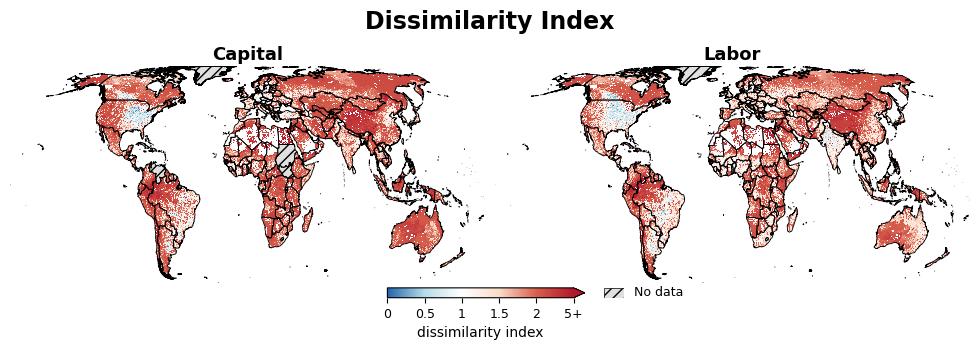

In [28]:
##### Global side-by-side map: capital (left) vs labor (right)

# set custom colormap — lighter blue and lighter red at the inner steps
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "blue_white_red",
    ["#2166ac", "#b8dce8", "#ffffff", "#fbdcc9", "#d6604d", "#b2182b"]
)
custom_cmap.set_over("#67001f")  # color for the 5+ triangle
custom_cmap.set_bad(color='none')

bounds = [0, 0.5, 1, 1.5, 2, 5]
labels = ['0', '0.5', '1', '1.5', '2', '5+']

positions = np.linspace(0, 1, len(bounds))

def forward(x):
    return np.interp(x, bounds, positions)

def inverse(x):
    return np.interp(x, positions, bounds)

norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

no_data_color = "#e0e0e0"

# --- Size figure to match the actual map aspect ratio ---
minx, miny, maxx, maxy = country_boundaries.total_bounds
map_aspect = (maxx - minx) / (maxy - miny)   # width / height of ONE map

panel_width = 5
panel_height = panel_width / map_aspect
fig_width = panel_width * 2
fig_height = panel_height * 1.5  # small headroom for titles/colorbar, not 7.5

fig, axes = plt.subplots(
    1, 2, figsize=(fig_width, fig_height), sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.02}
)

panels = [
    (di_grid_capital.squeeze(), "has_capital_data", "Capital", axes[0]),
    (di_grid_labor.squeeze(),   "has_labor_data",   "Labor",   axes[1]),
]

for value_plot, data_flag_col, title, ax in panels:

    country_boundaries[country_boundaries[data_flag_col] == 0].plot(
        ax=ax, facecolor=no_data_color, edgecolor="none", hatch="///", zorder=1
    )
    country_boundaries.plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=0.6, zorder=2
    )
    im = value_plot.plot(
        ax=ax, cmap=custom_cmap, norm=norm,
        add_colorbar=False, add_labels=False, zorder=0
    )

    ax.set_axis_off()
    ax.set_title(title, fontsize=13, weight='bold', pad=4)

axes[0].set_xlim(minx, maxx)
axes[0].set_ylim(miny, maxy)

fig.suptitle("Dissimilarity Index", fontsize=17, weight='bold', y=0.98)
fig.subplots_adjust(top=0.86, bottom=0.14, left=0.02, right=0.98)

# --- Shared colorbar ---
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    location="bottom",
    fraction=0.04,
    pad=0.02,
    shrink=0.35,
    extend='max',
    extendfrac=0.06,
)
cbar.set_label("dissimilarity index", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

fig.canvas.draw()

# --- No-data swatch ---
cbar_pos = cbar.ax.get_position()
swatch_size = 0.02
gap = 0.03

legend_ax = fig.add_axes([
    cbar_pos.x1 + gap, cbar_pos.y0, swatch_size, cbar_pos.height
])
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1, facecolor=no_data_color, edgecolor="black",
    linewidth=0.5, hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.axis("off")

fig.text(
    cbar_pos.x1 + gap + swatch_size + 0.01,
    cbar_pos.y0 + cbar_pos.height / 2,
    "No data", fontsize=9, va="center", ha="left"
)

plt.show()
fig.savefig(f"{fd}/DI_raster_capital_labor.png", dpi=300, bbox_inches='tight')

In [29]:
##### Prep AOA data

aoa_grid_labor = rio.open_rasterio(f'{fd}/AOA_labor.tif')
aoa_grid_capital = rio.open_rasterio(f'{fd}/AOA_capital.tif')

# align crs (same projection as DI plot)
aoa_grid_labor = aoa_grid_labor.rio.reproject(crs)
aoa_grid_capital = aoa_grid_capital.rio.reproject(crs)

# match grid exactly to production/DI grids for consistent extent
aoa_grid_labor = aoa_grid_labor.rio.reproject_match(di_grid_capital)
aoa_grid_capital = aoa_grid_capital.rio.reproject_match(di_grid_capital)

# mask to same valid pixels as DI (production-masked, has predictions)
aoa_grid_capital = aoa_grid_capital.where(di_grid_capital.notnull())
aoa_grid_labor = aoa_grid_labor.where(di_grid_labor.notnull())

aoa_plot_capital = aoa_grid_capital.squeeze()
aoa_plot_labor = aoa_grid_labor.squeeze()

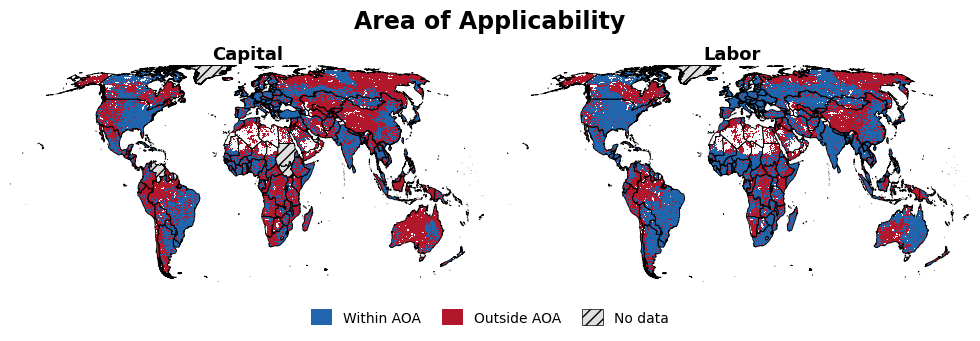

In [30]:
##### Global side-by-side map: AOA capital (left) vs labor (right)

# categorical colormap: 0 = outside AOA, 1 = within AOA
outside_color = "#b2182b"   # same red family as DI's high-dissimilarity end
within_color  = "#2166ac"   # same blue family as DI's low-dissimilarity end
no_data_color = "#e0e0e0"

aoa_cmap = mcolors.ListedColormap([outside_color, within_color])
aoa_cmap.set_bad(color='none')
aoa_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5], aoa_cmap.N)

# --- Size figure to match the actual map aspect ratio ---
minx, miny, maxx, maxy = country_boundaries.total_bounds
map_aspect = (maxx - minx) / (maxy - miny)

panel_width = 5
panel_height = panel_width / map_aspect
fig_width = panel_width * 2
fig_height = panel_height * 1.5

fig, axes = plt.subplots(
    1, 2, figsize=(fig_width, fig_height), sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.02}
)

panels = [
    (aoa_plot_capital, "has_capital_data", "Capital", axes[0]),
    (aoa_plot_labor,   "has_labor_data",   "Labor",   axes[1]),
]

for value_plot, data_flag_col, title, ax in panels:

    country_boundaries[country_boundaries[data_flag_col] == 0].plot(
        ax=ax, facecolor=no_data_color, edgecolor="none", hatch="///", zorder=1
    )
    country_boundaries.plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=0.6, zorder=2
    )
    im = value_plot.plot(
        ax=ax, cmap=aoa_cmap, norm=aoa_norm,
        add_colorbar=False, add_labels=False, zorder=0
    )

    ax.set_axis_off()
    ax.set_title(title, fontsize=13, weight='bold', pad=4)

axes[0].set_xlim(minx, maxx)
axes[0].set_ylim(miny, maxy)

fig.suptitle("Area of Applicability", fontsize=17, weight='bold', y=0.98)
fig.subplots_adjust(top=0.86, bottom=0.14, left=0.02, right=0.98)

# --- Categorical legend, centered underneath both panels ---
legend_handles = [
    Rectangle((0, 0), 1, 1, facecolor=within_color, edgecolor="none", label="Within AOA"),
    Rectangle((0, 0), 1, 1, facecolor=outside_color, edgecolor="none", label="Outside AOA"),
    Rectangle((0, 0), 1, 1, facecolor=no_data_color, edgecolor="black", linewidth=0.5,
              hatch="///", label="No data"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.02),
    handlelength=1.5,
    handleheight=1.5,
    columnspacing=1.5,
)

plt.show()
fig.savefig(f"{fd}/AOA_raster_capital_labor.png", dpi=300, bbox_inches='tight')

In [31]:
##### Prep production data (aligned to same grid as AOA/DI)

# here we just need a log-scaled, positive-only version aligned to AOA extent
production_capital = production.where(production > 0)
production_labor = production.where(production > 0)

log_prod_capital = np.log10(production_capital.squeeze())
log_prod_labor = np.log10(production_labor.squeeze())
# log_prod_capital = production_capital.squeeze()
# log_prod_labor = production_labor.squeeze()


# shared color scale across both panels — use robust percentiles, not raw min/max,
# so a handful of extreme outlier pixels don't wash out the rest of the scale
all_log_prod = np.concatenate([
    log_prod_capital.values[np.isfinite(log_prod_capital.values)],
    log_prod_labor.values[np.isfinite(log_prod_labor.values)],
])

vmin_log = np.percentile(all_log_prod, 1)
vmax_log = np.percentile(all_log_prod, 99)

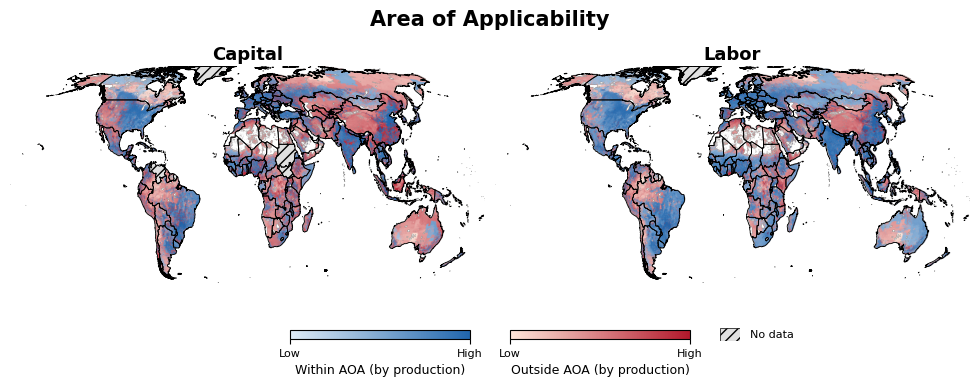

In [32]:
##### Global side-by-side map: AOA-by-production, capital (left) vs labor (right)

within_cmap = mcolors.LinearSegmentedColormap.from_list(
    "light_to_dark_blue", ["#deebf7", "#2166ac"]
)
outside_cmap = mcolors.LinearSegmentedColormap.from_list(
    "light_to_dark_red", ["#fee5d9", "#b2182b"]
)
no_data_color = "#e0e0e0"

norm = mcolors.Normalize(vmin=vmin_log, vmax=vmax_log)

def build_rgba(aoa_da, log_prod_da):
    """Combine AOA category + log production into a single RGBA image."""
    aoa = aoa_da.values
    prod = log_prod_da.values

    h, w = aoa.shape
    rgba = np.zeros((h, w, 4), dtype=float)

    valid = np.isfinite(aoa) & np.isfinite(prod)
    within = valid & (aoa == 1)
    outside = valid & (aoa == 0)

    rgba[within] = within_cmap(norm(prod[within]))
    rgba[outside] = outside_cmap(norm(prod[outside]))

    return rgba

rgba_capital = build_rgba(aoa_plot_capital, log_prod_capital)
rgba_labor = build_rgba(aoa_plot_labor, log_prod_labor)

# raster's OWN bounds — use for imshow extent, not the country boundary bounds
raster_left, raster_bottom, raster_right, raster_top = aoa_plot_capital.rio.bounds()

# --- Size figure to match the actual map aspect ratio (still from boundaries, fine for sizing) ---
minx, miny, maxx, maxy = country_boundaries.total_bounds
map_aspect = (maxx - minx) / (maxy - miny)

panel_width = 5
panel_height = panel_width / map_aspect
fig_width = panel_width * 2
fig_height = panel_height * 1.6

fig, axes = plt.subplots(
    1, 2, figsize=(fig_width, fig_height), sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.02}
)

panels = [
    (rgba_capital, "has_capital_data", "Capital", axes[0]),
    (rgba_labor,   "has_labor_data",   "Labor",   axes[1]),
]

for rgba_img, data_flag_col, title, ax in panels:

    country_boundaries[country_boundaries[data_flag_col] == 0].plot(
        ax=ax, facecolor=no_data_color, edgecolor="none", hatch="///", zorder=1
    )
    country_boundaries.plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=0.6, zorder=2
    )

    ax.imshow(
        rgba_img,
        extent=[raster_left, raster_right, raster_bottom, raster_top],  # raster's own bounds
        origin="upper",
        zorder=0,
    )

    ax.set_axis_off()
    ax.set_title(title, fontsize=13, weight='bold', pad=4)

# axis zoom still uses country boundary bounds — separate from image placement
axes[0].set_xlim(minx, maxx)
axes[0].set_ylim(miny, maxy)

fig.suptitle("Area of Applicability", fontsize=15, weight='bold', y=0.98)
fig.subplots_adjust(top=0.86, bottom=0.20, left=0.02, right=0.98)

# --- Two colorbars underneath: Within AOA (blue) and Outside AOA (red), Low -> High only ---
sm_within = plt.cm.ScalarMappable(cmap=within_cmap, norm=norm)
sm_outside = plt.cm.ScalarMappable(cmap=outside_cmap, norm=norm)

cbar_ax_within = fig.add_axes([0.30, 0.08, 0.18, 0.025])
cbar_ax_outside = fig.add_axes([0.52, 0.08, 0.18, 0.025])

cbar_within = fig.colorbar(sm_within, cax=cbar_ax_within, orientation="horizontal")
cbar_outside = fig.colorbar(sm_outside, cax=cbar_ax_outside, orientation="horizontal")

for cbar, label in [(cbar_within, "Within AOA"), (cbar_outside, "Outside AOA")]:
    cbar.set_ticks([vmin_log, vmax_log])
    cbar.set_ticklabels(["Low", "High"])
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label(f"{label} (by production)", fontsize=9)

# --- No-data swatch ---
legend_ax = fig.add_axes([0.73, 0.075, 0.02, 0.035])
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1, facecolor=no_data_color, edgecolor="black",
    linewidth=0.5, hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.axis("off")
fig.text(0.76, 0.09, "No data", fontsize=8, va="center", ha="left")

plt.show()
fig.savefig(f"{fd}/AOA_production_capital_labor.png", dpi=300, bbox_inches='tight')